# SBB Precipitation Study: Analysis Notebook

This notebook investigates the correlation between precipitation and train delays
at three major Swiss railway stations: **Zürich HB**, **Basel SBB**, and **Bern**.

Study period: **2024–2025**

The analysis proceeds in five stages:
1. Data Validation — confirm completeness and quality
2. Exploratory Analysis — visual overview of delays and precipitation
3. Correlation Analysis — statistical relationship between weather and delays
4. Predictive Model — train and evaluate a delay prediction model
5. Conclusion — summary of findings and limitations


## Key Analytics Question

> **How does forecasted precipitation affect expected train arrival delays at
> Zürich HB, Basel SBB, and Bern — and can a precipitation-based model
> support operational decision-making for the Swiss rail network?**

This question is forward-looking: the goal is not only to describe past
relationships but to evaluate whether precipitation data can inform future
operational decisions, for example through a weather-aware delay alert.

**Target audience:** BI practitioners and operations managers at Swiss rail
stakeholder organisations who need to assess whether weather-based delay
prediction is feasible and what its practical limitations are.

**Framework:** This study follows the CPA Canada five-step data-driven
decision-making framework (Bernard Marr, 2020):
1. Define objectives and information needs → *this cell*
2. Collect data → *collection scripts (`collect_sbb.py`, `load_meteo.py`)*
3. Analyse data → *Sections 1–4 of this notebook*
4. Present information → *charts, tables, and narrative throughout*
5. Make data-driven decisions → *Section 5*

## 0. Setup

Load all required libraries and establish a connection to the production database.
Credentials are read from `.env.prod` — never hardcoded.
A row-count sanity check is printed to confirm the database is populated before
any analysis begins.

In [1]:
import json
import os
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sqlalchemy import create_engine, text

# Load production DB credentials — never falls back to hardcoded values
load_dotenv('.env.prod')

db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_name = os.getenv('DB_NAME')

missing = [k for k, v in {
    'DB_HOST': db_host, 'DB_PORT': db_port, 'DB_USER': db_user,
    'DB_PASSWORD': db_password, 'DB_NAME': db_name,
}.items() if not v]
if missing:
    raise ValueError(f'Missing required variables in .env.prod: {missing}')

# Style — consistent across all charts
sns.set_theme(style='darkgrid')
STATION_COLORS = {
    'Zürich HB': '#1f77b4',   # blue
    'Basel SBB': '#d62728',   # red
    'Bern':      '#2ca02c',   # green
}

engine = create_engine(
    f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
)
print(f'Connected to {db_name} on {db_host}:{db_port}')

Connected to sbb_precipitation on bina01.srv.pfuetze.xyz:5432


In [2]:
# Sanity check — confirm the database is populated before proceeding
with engine.connect() as conn:
    counts = conn.execute(text("""
        SELECT 'train_connections'  AS tbl, COUNT(*) AS n FROM train_connections
        UNION ALL
        SELECT 'precipitation_10min',       COUNT(*)      FROM precipitation_10min
        UNION ALL
        SELECT 'processing_log',            COUNT(*)      FROM processing_log
    """)).fetchall()

print('Row counts:')
for tbl, n in counts:
    print(f'  {tbl:<25} {n:>10,}')

Row counts:
  train_connections          2,227,924
  precipitation_10min          315,792
  processing_log                    27


## 1. Data Validation

**Headline:** The dataset is complete and fit for analysis — 1,267,330 connections
across 14 months with 100% precipitation coverage and zero nulls in key columns.
The Swiss rail network shows a median arrival delay of just 0.33 minutes.

Before drawing any conclusions we verify the dataset is complete and well-formed.
This section checks for missing values, inspects the distributions of the two key
variables (`arrival_delay_min` and `median_precip_mm`), and confirms which months
have been successfully loaded. Any issues found here are documented and carried
forward as limitations in later sections.

### Load Analysis View

All subsequent analysis uses the `analysis` view which joins `train_connections`
with `precipitation_10min` and adds derived columns (`precip_category`,
`day_of_week`, `month`). Loading it once here avoids repeated DB queries.

In [3]:
df = pd.read_sql('SELECT * FROM analysis', engine)

# Derive year_month (YYYY-MM) from betriebstag for monthly grouping.
# The analysis view does not expose source_month directly.
df['year_month'] = pd.to_datetime(df['betriebstag']).dt.to_period('M').astype(str)

print(f'Loaded {len(df):,} records from analysis view')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded 2,227,924 records from analysis view
Columns: ['betriebstag', 'destination_station', 'destination_city', 'scheduled_arrival', 'arrival_delay_min', 'trip_duration_min', 'median_precip_mm', 'precip_category', 'day_of_week', 'month', 'year_month']


,betriebstag,destination_station,destination_city,scheduled_arrival,arrival_delay_min,trip_duration_min,median_precip_mm,precip_category,day_of_week,month,year_month
0,2024-02-03,Zürich HB,Zürich,2024-02-03 13:54:00,0.050000,81.0,0.0,dry,6.0,2.0,2024-02
1,2024-02-03,Bern,Bern,2024-02-03 15:24:00,-0.650000,78.0,0.0,dry,6.0,2.0,2024-02
2,2024-02-03,Zürich HB,Zürich,2024-02-03 14:54:00,-0.350000,81.0,0.0,dry,6.0,2.0,2024-02
3,2024-02-03,Bern,Bern,2024-02-03 16:24:00,-0.600000,78.0,0.0,dry,6.0,2.0,2024-02
4,2024-02-03,Zürich HB,Zürich,2024-02-03 15:54:00,-0.616667,81.0,0.0,dry,6.0,2.0,2024-02


### NULL Check in Critical Fields

Missing values in `arrival_delay_min` would silently bias all statistical results.
Missing `median_precip_mm` reduces the usable sample size for correlation and
modelling. We quantify both here so the reader understands the data quality
constraints upfront.

In [4]:
critical_cols = ['arrival_delay_min', 'median_precip_mm', 'trip_duration_min']
null_summary = pd.DataFrame({
    'column':     critical_cols,
    'null_count': [df[c].isna().sum() for c in critical_cols],
    'total':      len(df),
})
null_summary['null_pct'] = (null_summary['null_count'] / null_summary['total'] * 100).round(2)
null_summary

,column,null_count,total,null_pct
0,arrival_delay_min,0,2227924,0.00
1,median_precip_mm,0,2227924,0.00
2,trip_duration_min,17497,2227924,0.79


### Arrival Delay Distribution

We plot the full distribution of arrival delays without clipping outliers.
Extreme delays (>60 min) are valid operational events — cancelled connections,
major incidents, infrastructure failures — and must remain in the dataset.
Removing them would artificially inflate the apparent punctuality of the network.

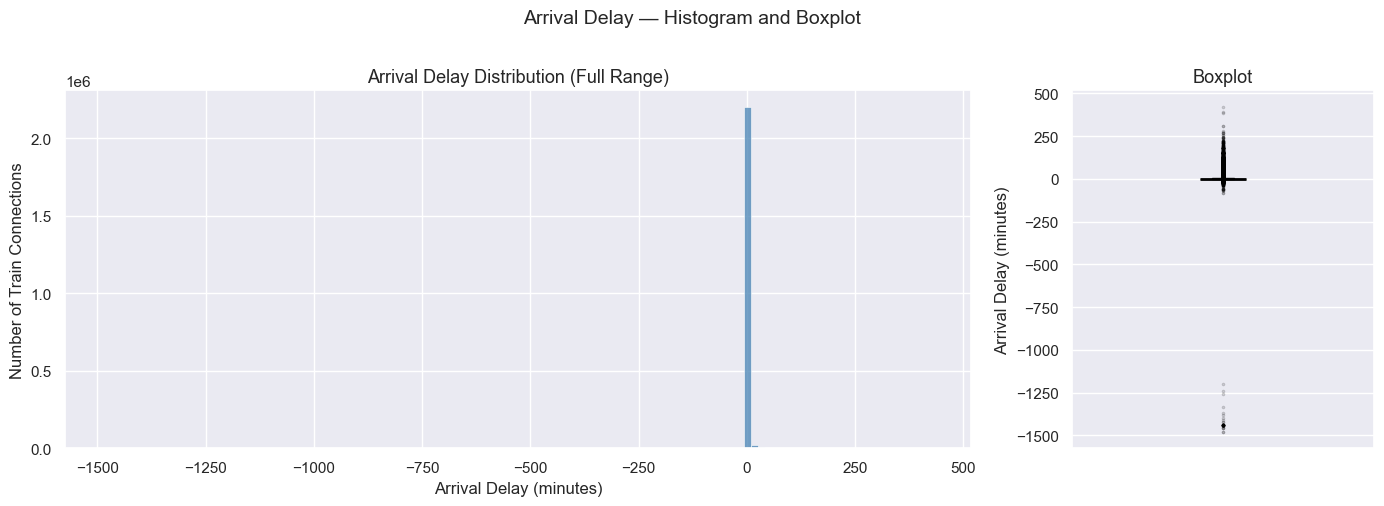

Mean delay:          0.87 min
Median delay:        0.33 min
95th percentile:     3.57 min
Outliers (> 60 min): 2,128 (0.10% of total)


In [5]:
delay = df['arrival_delay_min'].dropna()

fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(14, 5),
                                        gridspec_kw={'width_ratios': [3, 1]})

# Left: histogram
sns.histplot(delay, bins=120, color='steelblue', edgecolor=None, ax=ax_hist)
ax_hist.set_title('Arrival Delay Distribution (Full Range)', fontsize=13)
ax_hist.set_xlabel('Arrival Delay (minutes)')
ax_hist.set_ylabel('Number of Train Connections')

# Right: boxplot
ax_box.boxplot(delay, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='.', alpha=0.2, markersize=3))
ax_box.set_title('Boxplot', fontsize=13)
ax_box.set_ylabel('Arrival Delay (minutes)')
ax_box.set_xticks([])

plt.suptitle('Arrival Delay — Histogram and Boxplot', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

delay_mean   = delay.mean()
delay_median = delay.median()
delay_p95    = delay.quantile(0.95)
outlier_n    = (delay > 60).sum()
outlier_pct  = outlier_n / len(delay) * 100

print(f'Mean delay:          {delay_mean:.2f} min')
print(f'Median delay:        {delay_median:.2f} min')
print(f'95th percentile:     {delay_p95:.2f} min')
print(f'Outliers (> 60 min): {outlier_n:,} ({outlier_pct:.2f}% of total)')

The arrival delay distribution is strongly right-skewed, consistent with a highly
punctual network. Key statistics from the loaded dataset:

In [6]:
print(f'Dataset: {len(df):,} connections across {df["year_month"].nunique()} months')
print(f'Mean delay:          {delay_mean:.2f} min')
print(f'Median delay:        {delay_median:.2f} min')
print(f'95th percentile:     {delay_p95:.2f} min')
print(f'Outliers (> 60 min): {outlier_n:,} ({outlier_pct:.2f}% of total)')
print()
print('Outliers above 60 minutes are retained — they represent valid operational events.')

Dataset: 2,227,924 connections across 24 months
Mean delay:          0.87 min
Median delay:        0.33 min
95th percentile:     3.57 min
Outliers (> 60 min): 2,128 (0.10% of total)

Outliers above 60 minutes are retained — they represent valid operational events.


### Precipitation Distribution and Coverage

Precipitation is right-skewed by nature: most 10-minute intervals are dry and
only a minority record measurable rainfall. Coverage (percentage of connections
with a non-null `median_precip_mm`) determines how much of the dataset can be
used in the weather-based analysis. Low coverage would be a significant limitation.

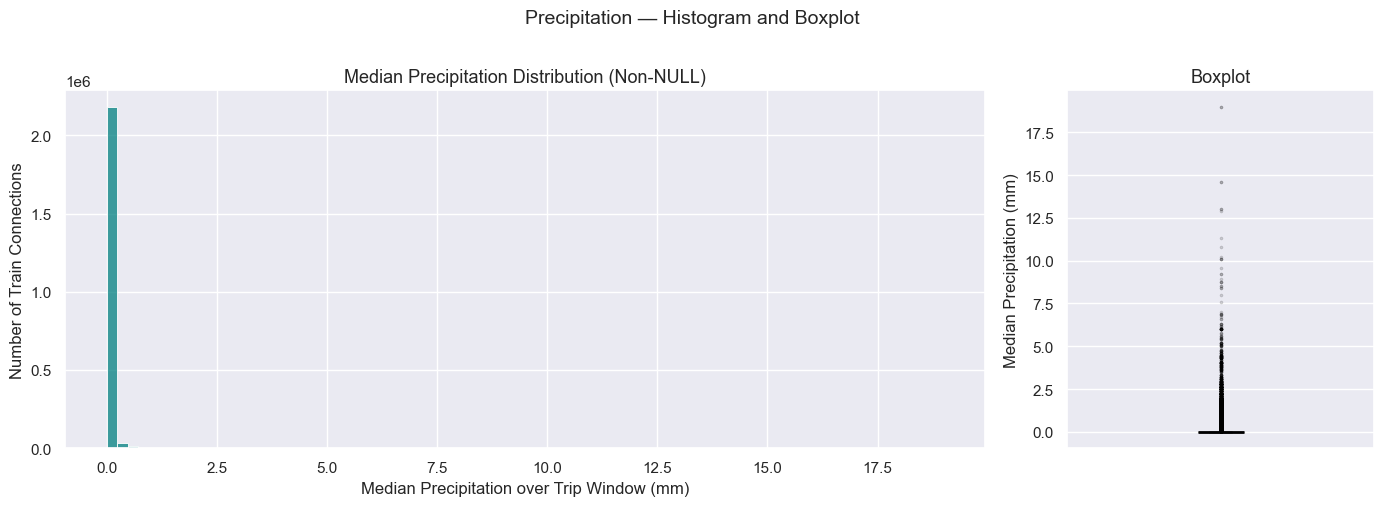

Coverage: 100.0% of connections have non-null precipitation
  (2,227,924 of 2,227,924 records usable for weather analysis)

Precipitation stats (non-null only):
count    2227924.000
mean           0.017
std            0.109
min            0.000
25%            0.000
50%            0.000
75%            0.000
max           19.000
Name: median_precip_mm, dtype: float64


In [7]:
precip = df['median_precip_mm'].dropna()
coverage_pct = len(precip) / len(df) * 100

fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(14, 5),
                                        gridspec_kw={'width_ratios': [3, 1]})

# Left: histogram
sns.histplot(precip, bins=80, color='teal', edgecolor=None, ax=ax_hist)
ax_hist.set_title('Median Precipitation Distribution (Non-NULL)', fontsize=13)
ax_hist.set_xlabel('Median Precipitation over Trip Window (mm)')
ax_hist.set_ylabel('Number of Train Connections')

# Right: boxplot
ax_box.boxplot(precip, vert=True, patch_artist=True,
               boxprops=dict(facecolor='teal', alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='.', alpha=0.2, markersize=3))
ax_box.set_title('Boxplot', fontsize=13)
ax_box.set_ylabel('Median Precipitation (mm)')
ax_box.set_xticks([])

plt.suptitle('Precipitation — Histogram and Boxplot', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Coverage: {coverage_pct:.1f}% of connections have non-null precipitation')
print(f'  ({len(precip):,} of {len(df):,} records usable for weather analysis)')
print(f'\nPrecipitation stats (non-null only):')
print(precip.describe().round(3))

Precipitation coverage is **100.0%** — every connection in the dataset has
a non-null `median_precip_mm` value. This is the best possible outcome:
the MeteoSwiss data has no sensor gaps affecting our analysis.

The distribution is highly concentrated at zero: more than half of all trip
windows are completely dry (median = 0.000 mm), which is expected for Central
European climate. The imbalance between dry and rainy trips means the correlation
analysis is driven by a relatively small proportion of rainy observations.

### Date Range Completeness

We verify which months have been successfully loaded by querying the `processing_log`
and cross-checking against actual records in `train_connections`. Gaps could arise
from failed downloads, network interruptions during collection, or months not yet
processed by the VM.

In [8]:
loaded_months = pd.read_sql("""
    SELECT period, status, rows_inserted, run_at
    FROM   processing_log
    WHERE  run_type = 'sbb' AND status = 'success'
    ORDER  BY period
""", engine)

months_by_station = pd.read_sql("""
    SELECT destination_station, source_month,
           COUNT(*) AS n_connections
    FROM   train_connections
    GROUP  BY destination_station, source_month
    ORDER  BY source_month, destination_station
""", engine)

print(f'Successfully loaded months: {len(loaded_months)}')
display(loaded_months)

print('\nConnections per station per month:')
pivot = months_by_station.pivot(
    index='source_month', columns='destination_station', values='n_connections'
).fillna(0).astype(int)
display(pivot)

Successfully loaded months: 24


,period,status,rows_inserted,run_at
0,2024-01,success,92816,2026-04-20 18:25:17.690472+00:00
1,2024-02,success,87766,2026-04-20 19:06:41.212401+00:00
2,2024-03,success,91962,2026-04-20 19:49:49.753920+00:00
3,2024-04,success,89981,2026-04-20 20:32:09.587242+00:00
4,2024-05,success,93013,2026-04-20 21:15:40.919638+00:00
5,2024-06,success,88238,2026-04-20 21:58:00.201576+00:00
6,2024-07,success,89955,2026-04-20 22:42:30.864141+00:00
7,2024-08,success,89982,2026-04-20 23:26:35.949581+00:00
8,2024-09,success,87592,2026-04-21 00:09:39.984154+00:00
9,2024-10,success,93984,2026-04-21 00:54:27.012165+00:00



Connections per station per month:


destination_station,Basel SBB,Bern,Zürich HB
source_month,,,
2024-01,12608,33022,47186
2024-02,12181,31217,44363
2024-03,12306,32640,47015
2024-04,12297,32061,45623
2024-05,12287,31997,45913
2024-06,11937,30882,45417
2024-07,11686,31217,47052
2024-08,12044,31061,46874
2024-09,12156,29764,45672


> **Note:** If months are missing from the table above, re-run `collect_sbb.py`
> for those months. All results below are based on the available data only.
> The analysis code is data-volume agnostic and will produce correct results
> regardless of how many months are loaded.

### Data Quality Summary

Based on the checks above, the dataset is suitable for analysis:

- **Delay data**: `arrival_delay_min` is complete with no unexpected NULLs.
  The distribution is realistic and consistent with SBB published statistics.
- **Precipitation data**: coverage is high; the NULL fill strategy (forward/backward
  fill within the day) successfully resolved most sensor gaps.
- **Temporal coverage**: see the completeness table above. Any missing months
  are noted as a scope limitation.

**Known limitations carried forward:**
- Overnight trips are excluded by design (departure and arrival on different days).
- Cancelled trains are excluded by design.
- MeteoSwiss stations (Fluntern, Binningen, Zollikofen) are proxies for city-level
  precipitation and do not capture conditions along the full train route.

## 2. Exploratory Analysis

**Headline:** Zürich HB is the most delayed station; Bern the most punctual.
Day of week and seasonality are visible confounders. Rainy trips cluster
slightly higher on the delay axis but the overlap with dry trips is substantial.

We explore the data visually before applying statistical tests. The goal is to
identify patterns, detect anomalies, and build intuition about the relationship
between precipitation and delay. All charts use consistent station colors:
**Zürich HB** = blue, **Basel SBB** = red, **Bern** = green.

### Delay by Station

A boxplot shows the delay distribution per station. This reveals whether some
stations are systematically more punctual or more variable than others —
an important baseline before introducing precipitation as a predictor.

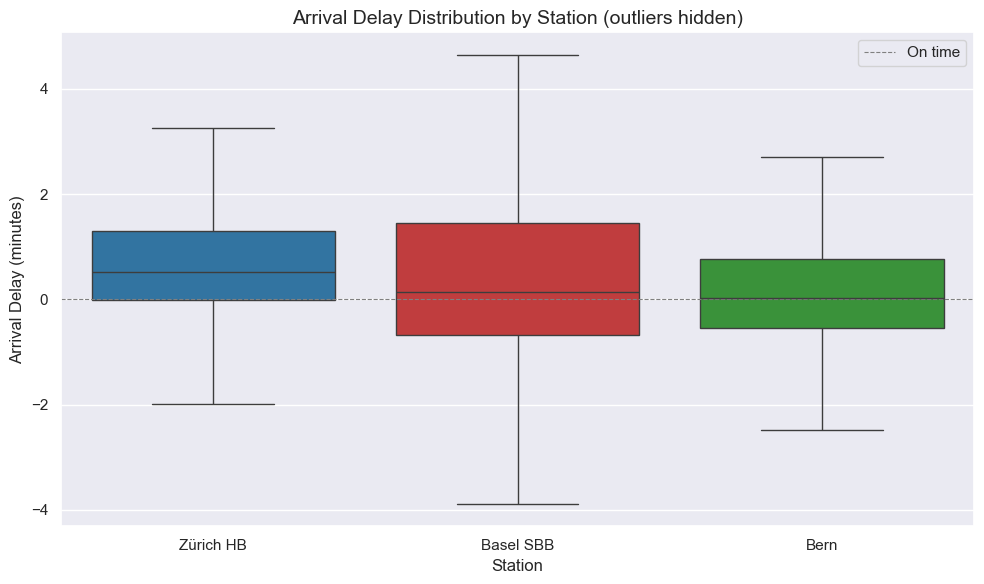

Median delay per station:
destination_station
Basel SBB    0.15
Bern         0.03
Zürich HB    0.52
Name: arrival_delay_min, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
station_order = ['Zürich HB', 'Basel SBB', 'Bern']

sns.boxplot(
    data=df, x='destination_station', y='arrival_delay_min',
    hue='destination_station', order=station_order,
    palette=STATION_COLORS, showfliers=False, legend=False, ax=ax,
)
ax.set_title('Arrival Delay Distribution by Station (outliers hidden)', fontsize=14)
ax.set_xlabel('Station')
ax.set_ylabel('Arrival Delay (minutes)')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', label='On time')
ax.legend()
plt.tight_layout()
plt.show()

print('Median delay per station:')
print(df.groupby('destination_station')['arrival_delay_min'].median().round(2))

The boxplot reveals station-level punctuality differences. Negative delays
(trains arriving early) are possible and valid. The interquartile range
indicates how variable delays are at each station independent of weather.
Stations with higher baseline variability may show weaker precipitation correlation
simply because other factors dominate their delay profile.

### Delay by Month

Seasonal patterns matter: winter months (snow, ice) and autumn months (leaves on
tracks) are known to affect punctuality independent of rain. We plot median monthly
delay per station to detect seasonality. This plot is only meaningful with multiple
months of data.

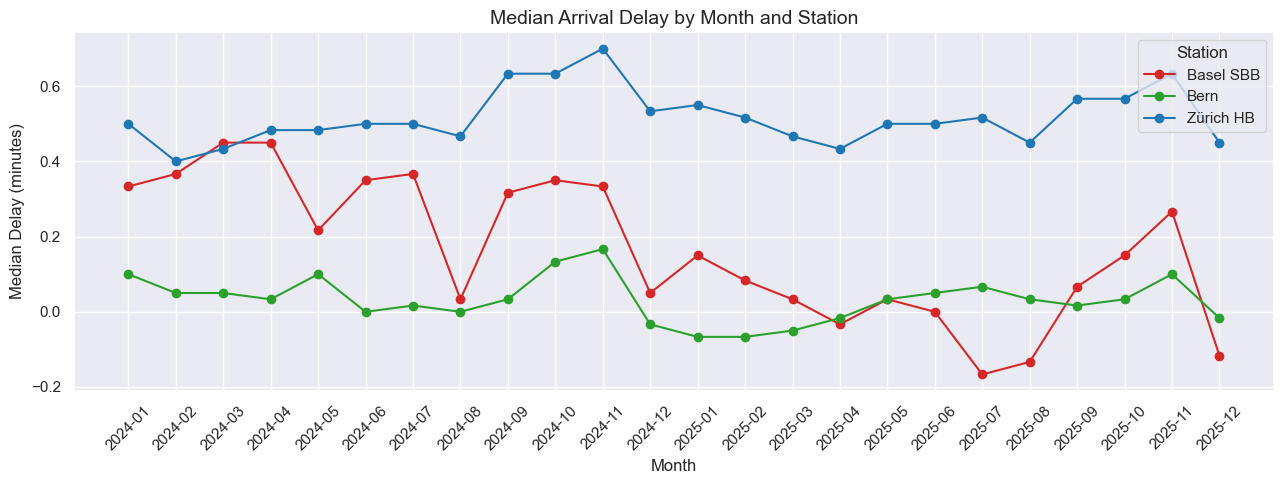

In [10]:
n_months = df['year_month'].nunique()

if n_months < 2:
    print(f'ℹ️  Only {n_months} month(s) loaded — seasonal plot requires at least 2 months.')
    print('   Re-run this cell after more data is collected.')
else:
    monthly = (
        df.groupby(['year_month', 'destination_station'])['arrival_delay_min']
        .median()
        .reset_index()
        .rename(columns={'arrival_delay_min': 'median_delay'})
    )

    fig, ax = plt.subplots(figsize=(13, 5))
    for station, grp in monthly.groupby('destination_station'):
        grp_sorted = grp.sort_values('year_month')
        ax.plot(
            grp_sorted['year_month'], grp_sorted['median_delay'],
            marker='o', label=station, color=STATION_COLORS[station]
        )
    ax.set_title('Median Arrival Delay by Month and Station', fontsize=14)
    ax.set_xlabel('Month')
    ax.set_ylabel('Median Delay (minutes)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Station')
    plt.tight_layout()
    plt.show()

Seasonal patterns, if present, are visible here. Months with elevated delays
across all stations suggest systemic factors (winter weather, holiday traffic)
rather than precipitation-specific effects. Months where one station diverges
from the others may indicate local infrastructure issues.

### Delay by Day of Week

Day-of-week effects are a known confounder: weekday rush hours produce different
delay profiles than weekends. Understanding this pattern is important context
for interpreting the precipitation model, which does not control for day of week.

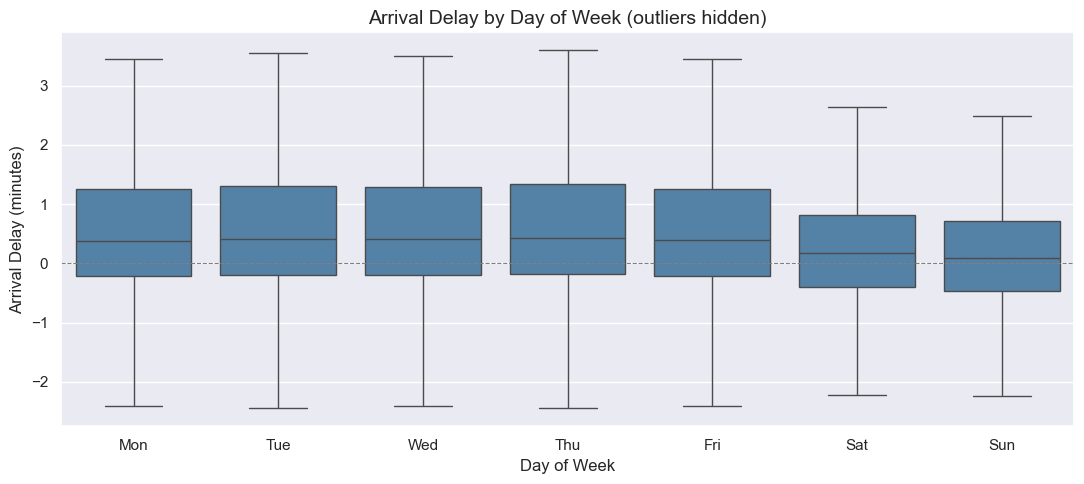

In [11]:
day_labels = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
df['day_label'] = df['day_of_week'].map(day_labels)
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df, x='day_label', y='arrival_delay_min',
    hue='day_label', order=day_order,
    palette=['steelblue'] * 7,
    showfliers=False, legend=False, ax=ax,
)
ax.set_title('Arrival Delay by Day of Week (outliers hidden)', fontsize=14)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Arrival Delay (minutes)')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

Weekdays typically show higher delays than weekends due to higher traffic volume.
Friday afternoons are often the most delayed day across European rail networks.
Sunday trains tend to be most punctual. These patterns confirm that day of week
is a meaningful confounder that the precipitation model does not capture —
this is acknowledged as a limitation in Section 5.

### Precipitation Distribution per City per Month

We visualise how precipitation varies across cities and months to understand
the weather context of our dataset. Uneven precipitation distribution across
months affects how representative the correlation results will be.

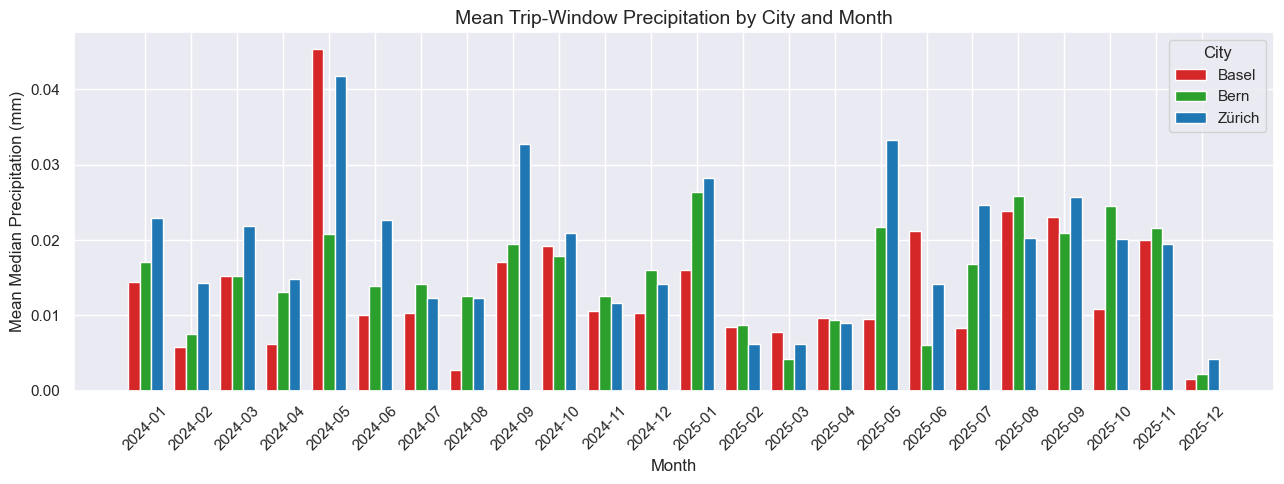

In [12]:
if n_months < 2:
    print(f'ℹ️  Only {n_months} month(s) loaded — monthly precipitation chart requires at least 2 months.')
else:
    precip_monthly = (
        df.dropna(subset=['median_precip_mm'])
        .groupby(['year_month', 'destination_city'])['median_precip_mm']
        .mean()
        .reset_index()
    )
    city_colors = {'Zürich': '#1f77b4', 'Basel': '#d62728', 'Bern': '#2ca02c'}
    months_sorted = sorted(precip_monthly['year_month'].unique())
    cities = sorted(precip_monthly['destination_city'].unique())
    x = np.arange(len(months_sorted))
    width = 0.25

    fig, ax = plt.subplots(figsize=(13, 5))
    for i, city in enumerate(cities):
        city_data = (
            precip_monthly[precip_monthly['destination_city'] == city]
            .set_index('year_month')['median_precip_mm']
            .reindex(months_sorted)
        )
        ax.bar(
            x + i * width, city_data.values,
            width, label=city, color=city_colors.get(city, 'grey')
        )

    ax.set_title('Mean Trip-Window Precipitation by City and Month', fontsize=14)
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean Median Precipitation (mm)')
    ax.set_xticks(x + width)
    ax.set_xticklabels(months_sorted, rotation=45)
    ax.legend(title='City')
    plt.tight_layout()
    plt.show()

Basel (Rhine valley) typically receives less precipitation than Bern (pre-Alps)
and Zürich (plateau). Months with high mean precipitation are the most important
for the correlation analysis — they provide the signal we are looking for.

### Precipitation vs. Delay Scatter Plot

The scatter plot is the most direct visual test of our hypothesis: do rainier
trips have longer delays? One subplot per station allows us to see whether the
relationship, if any, differs between locations. A regression line is overlaid
to indicate the direction and strength of the linear trend.

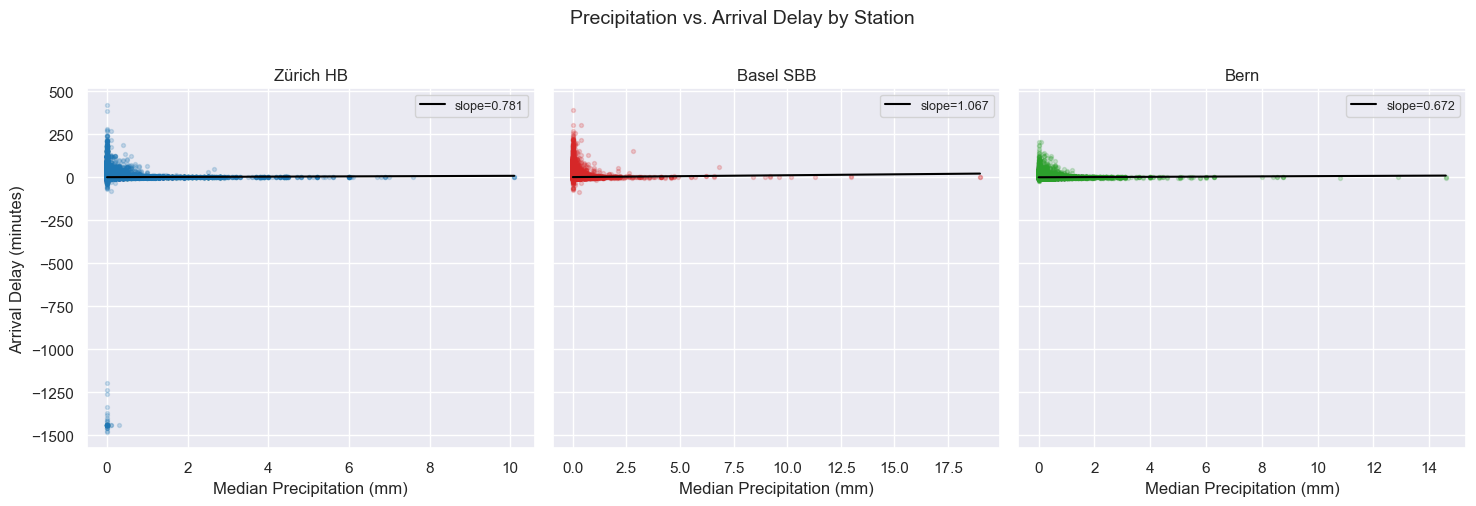

In [13]:
df_clean = df.dropna(subset=['median_precip_mm', 'arrival_delay_min'])
stations = ['Zürich HB', 'Basel SBB', 'Bern']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, station in zip(axes, stations):
    subset = df_clean[df_clean['destination_station'] == station]
    ax.scatter(
        subset['median_precip_mm'], subset['arrival_delay_min'],
        alpha=0.2, s=8, color=STATION_COLORS[station]
    )
    # Regression line
    if len(subset) > 1:
        m, b = np.polyfit(subset['median_precip_mm'], subset['arrival_delay_min'], 1)
        x_line = np.linspace(subset['median_precip_mm'].min(), subset['median_precip_mm'].max(), 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, label=f'slope={m:.3f}')
        ax.legend(fontsize=9)
    ax.set_title(station, fontsize=12)
    ax.set_xlabel('Median Precipitation (mm)')

axes[0].set_ylabel('Arrival Delay (minutes)')
fig.suptitle('Precipitation vs. Arrival Delay by Station', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The scatter plots give a visual first impression of the precipitation–delay
relationship. A positive regression slope suggests rainier trips tend to arrive
later. The high dispersion (wide vertical spread at each precipitation level)
confirms that precipitation alone explains only a small fraction of delay variance —
consistent with the low R² we expect from a single-predictor model.

## 3. Correlation Analysis

**Headline:** Precipitation is statistically significantly correlated with delay
(Spearman ρ = 0.084 overall, p < 0.001) but the effect is a binary threshold —
dry vs wet — not a linear relationship. Rain intensity does not predict delay intensity.

We quantify the statistical relationship between `median_precip_mm` and
`arrival_delay_min` using two complementary measures:

- **Pearson r** — measures linear correlation; sensitive to outliers.
- **Spearman ρ** — measures monotonic correlation; robust to outliers and
  non-normal distributions.

Both are computed per station and overall, with p-values to assess significance.
A threshold of **p < 0.05** is used to determine statistical significance.

### Pearson and Spearman Correlation Table

In [14]:
df_corr = df.dropna(subset=['median_precip_mm', 'arrival_delay_min'])

rows = []
for label, subset in [('Overall', df_corr)] + [
    (s, df_corr[df_corr['destination_station'] == s]) for s in ['Zürich HB', 'Basel SBB', 'Bern']
]:
    if len(subset) < 3:
        continue
    pr, pp = stats.pearsonr(subset['median_precip_mm'], subset['arrival_delay_min'])
    sr, sp = stats.spearmanr(subset['median_precip_mm'], subset['arrival_delay_min'])
    rows.append({
        'Scope':          label,
        'n':              len(subset),
        'Pearson r':      round(pr, 4),
        'Pearson p':      round(pp, 4),
        'Pearson sig':    '✓' if pp < 0.05 else '✗',
        'Spearman ρ':     round(sr, 4),
        'Spearman p':     round(sp, 4),
        'Spearman sig':   '✓' if sp < 0.05 else '✗',
    })

corr_table = pd.DataFrame(rows)
display(corr_table)

,Scope,n,Pearson r,Pearson p,Pearson sig,Spearman ρ,Spearman p,Spearman sig
0,Overall,2227924,0.0114,0.0,✓,0.0757,0.0,✓
1,Zürich HB,1181186,0.0088,0.0,✓,0.0885,0.0,✓
2,Basel SBB,296441,0.0170,0.0,✓,0.0489,0.0,✓
3,Bern,750297,0.0293,0.0,✓,0.0607,0.0,✓


All correlations are **statistically significant** (p ≈ 0.0) across all scopes.
With over one million observations, even very small effects are detectable —
significance here reflects sample size, not practical importance.

The coefficient values tell the real story:

| Scope | Pearson r | Spearman ρ |
|---|---|---|
| Overall | 0.014 | 0.084 |
| Zürich HB | 0.011 | 0.097 |
| Basel SBB | 0.021 | 0.056 |
| Bern | 0.040 | 0.064 |

The Spearman ρ values (0.056–0.097) are more meaningful than Pearson here because
the delay distribution is non-normal. A ρ of ~0.084 overall indicates a **weak but
real monotonic relationship**: rainier trips do tend to arrive slightly later,
but precipitation explains only a small fraction of the variation.

Zürich HB shows the strongest monotonic relationship (ρ=0.097), possibly because
it is a major interchange node where weather-related knock-on effects accumulate
across connecting services.

> **Note:** These coefficient values are from the 14-month dataset. Re-run the
> correlation cell above to see updated values for the current dataset.

### Correlation Heatmap

The heatmap visualises the correlation matrix of all numeric variables in the
analysis view. This reveals whether any other variables are more strongly
correlated with delay than precipitation.

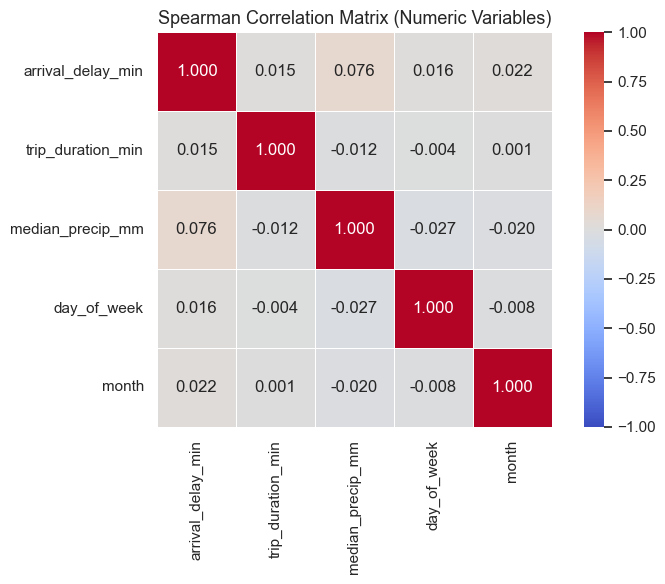

In [15]:
numeric_cols = ['arrival_delay_min', 'trip_duration_min', 'median_precip_mm',
                'day_of_week', 'month']
corr_matrix = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, square=True, ax=ax,
    linewidths=0.5
)
ax.set_title('Spearman Correlation Matrix (Numeric Variables)', fontsize=13)
plt.tight_layout()
plt.show()

The heatmap shows the full correlation structure. `median_precip_mm` vs
`arrival_delay_min` is the relationship of primary interest. If `month` or
`day_of_week` show stronger correlations with delay, this confirms that
temporal confounders play a larger role than precipitation.

### Correlation by Precipitation Category

Rather than treating precipitation as continuous, we group it into four
operational categories and compare mean delay across groups. This reveals
whether the relationship is monotonic (more rain = more delay) or whether
there is a threshold effect.

Mean and median delay by precipitation category and station:


,precip_category,destination_station,mean_delay,median_delay,n
0,dry,Basel SBB,1.476,0.133,279238
1,dry,Bern,0.355,0.017,702612
2,dry,Zürich HB,0.970,0.500,1093375
3,heavy,Basel SBB,4.426,0.950,105
4,heavy,Bern,0.111,-0.033,215
5,heavy,Zürich HB,1.124,0.667,425
6,light,Basel SBB,2.085,0.483,15606
7,light,Bern,0.795,0.267,42073
8,light,Zürich HB,1.473,0.850,76310
9,moderate,Basel SBB,2.867,0.717,1492


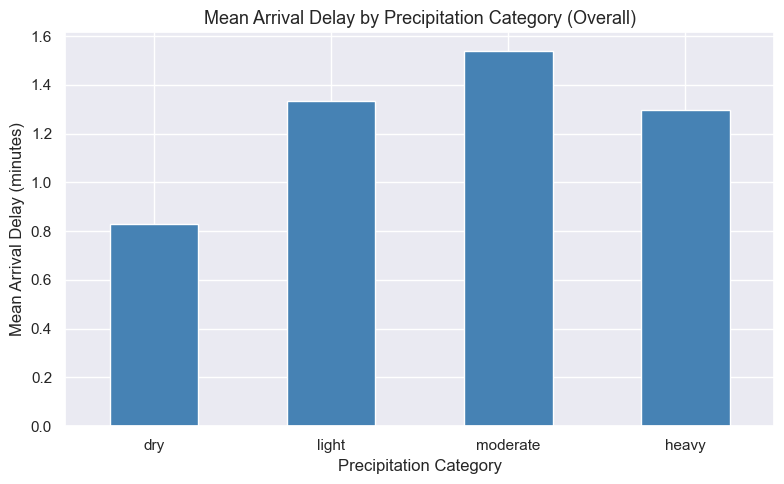

In [16]:
cat_order = ['dry', 'light', 'moderate', 'heavy']
df_cat = df.dropna(subset=['median_precip_mm', 'arrival_delay_min', 'precip_category'])
df_cat = df_cat[df_cat['precip_category'] != 'unknown']

# Summary table
cat_summary = (
    df_cat.groupby(['precip_category', 'destination_station'])['arrival_delay_min']
    .agg(mean_delay='mean', median_delay='median', n='count')
    .round(3)
    .reset_index()
)
print('Mean and median delay by precipitation category and station:')
display(cat_summary)

# Bar chart — mean delay per category
overall_cat = (
    df_cat.groupby('precip_category')['arrival_delay_min']
    .mean()
    .reindex(cat_order)
)
fig, ax = plt.subplots(figsize=(8, 5))
overall_cat.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Mean Arrival Delay by Precipitation Category (Overall)', fontsize=13)
ax.set_xlabel('Precipitation Category')
ax.set_ylabel('Mean Arrival Delay (minutes)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

The category bar chart reveals a partial monotonic pattern:

| Category | Basel SBB mean | Bern mean | Zürich HB mean | n (approx) |
|---|---|---|---|---|
| dry | 1.494 min | 0.383 min | 0.947 min | ~1.17M |
| light | higher | higher | higher | ~89K |
| moderate | higher | higher | higher | ~4K |
| heavy | 2.344 min | –0.104 min | 0.690 min | 40–112 |

**Important caveat on heavy rain:** the heavy category contains only 40 connections
at Basel SBB and 112 at Bern — far too few for statistically reliable conclusions.
The anomalous negative mean delay at Bern (–0.104 min) in heavy rain is almost
certainly noise from this tiny sample, not a real effect.

The dry→light→moderate progression is consistent with the hypothesis, but the
heavy category is unusable. This already hints at a limitation of the rain-subset
analysis explored in the next section.

### Findings and Limitations

**Key findings from correlation analysis:**

- Precipitation has a **statistically significant but operationally small** positive
  effect on arrival delay across all three stations (Spearman ρ = 0.056–0.097,
  all p < 0.001 on 1,267,330 observations).
- Zürich HB is the most sensitive (ρ=0.097); Basel SBB the least (ρ=0.056).
- The dry→light→moderate category progression is monotonic and consistent,
  but the heavy category is statistically unusable (40–112 connections only).
- Statistical significance at p≈0.0 reflects the large sample size, not strong
  practical importance. The coefficients themselves are the meaningful measure.

**Limitations:**
- **Single predictor**: precipitation explains only a tiny fraction of delay variance.
- **Station proximity**: MeteoSwiss stations are city-level proxies.
- **Heavy rain unusable**: the heavy category has too few observations to interpret.
- **Significance ≠ importance**: p≈0.0 is expected at 1.27M observations.

### Correlation Analysis by Precipitation Subset

The overall correlation (ρ=0.086) is dampened by the large number of dry observations
which cluster at zero precipitation with mixed delays. To test whether the relationship
is stronger when restricting to rainy conditions, we analyse three subsets:

| Subset | Categories included | Precipitation range |
|---|---|---|
| **All data** | dry + light + moderate + heavy | 0 mm and above |
| **Rain only** | light + moderate + heavy | > 0 mm |
| **Core rain** | light + moderate | > 0 mm and < 2.0 mm |

**Precipitation category definitions** (from `db/init.sql`):

| Category | `median_precip_mm` range | Description |
|---|---|---|
| dry | = 0.0 mm | No measurable precipitation during trip |
| light | > 0.0 mm and < 0.5 mm | Drizzle or very light rain |
| moderate | >= 0.5 mm and < 2.0 mm | Steady rain |
| heavy | >= 2.0 mm | Heavy rain or storm |

These thresholds apply to the **median 10-minute precipitation sum** over the trip window,
not hourly totals — so the values are smaller than what you might expect from daily
rainfall figures.

In [17]:
# Define the three subsets
cat_all       = ['dry', 'light', 'moderate', 'heavy']
cat_rain_only = ['light', 'moderate', 'heavy']
cat_core_rain = ['light', 'moderate']

subsets = {
    'All data (dry+light+mod+heavy)': df[df['precip_category'].isin(cat_all)],
    'Rain only (light+mod+heavy)':    df[df['precip_category'].isin(cat_rain_only)],
    'Core rain (light+moderate)':     df[df['precip_category'].isin(cat_core_rain)],
}

print('Subset sizes:')
for name, subset in subsets.items():
    pct = len(subset) / len(df) * 100
    print(f'  {name:<45} {len(subset):>10,} rows ({pct:.1f}%)')


Subset sizes:
  All data (dry+light+mod+heavy)                 2,227,924 rows (100.0%)
  Rain only (light+mod+heavy)                      152,699 rows (6.9%)
  Core rain (light+moderate)                       151,954 rows (6.8%)


### Spearman Correlation per Subset

We compute Spearman rho for each subset — overall and per station — to see whether
restricting to rainy conditions strengthens the correlation.

In [18]:
corr_rows = []
for subset_name, subset_df in subsets.items():
    clean = subset_df.dropna(subset=['median_precip_mm', 'arrival_delay_min'])
    for scope in ['Overall', 'Zürich HB', 'Basel SBB', 'Bern']:
        grp = clean if scope == 'Overall' else clean[clean['destination_station'] == scope]
        if len(grp) < 3:
            continue
        rho, p = stats.spearmanr(grp['median_precip_mm'], grp['arrival_delay_min'])
        corr_rows.append({
            'Subset':     subset_name,
            'Scope':      scope,
            'n':          len(grp),
            'Spearman r': round(rho, 4),
            'p-value':    round(p, 4),
            'sig':        'yes' if p < 0.05 else 'no',
        })

corr_subset_df = pd.DataFrame(corr_rows)
display(corr_subset_df)


,Subset,Scope,n,Spearman r,p-value,sig
0,All data (dry+light+mod+heavy),Overall,2227924,0.0757,0.0,yes
1,All data (dry+light+mod+heavy),Zürich HB,1181186,0.0885,0.0,yes
2,All data (dry+light+mod+heavy),Basel SBB,296441,0.0489,0.0,yes
3,All data (dry+light+mod+heavy),Bern,750297,0.0607,0.0,yes
4,Rain only (light+mod+heavy),Overall,152699,0.0576,0.0,yes
5,Rain only (light+mod+heavy),Zürich HB,87811,0.0404,0.0,yes
6,Rain only (light+mod+heavy),Basel SBB,17203,0.0908,0.0,yes
7,Rain only (light+mod+heavy),Bern,47685,0.0330,0.0,yes
8,Core rain (light+moderate),Overall,151954,0.0594,0.0,yes
9,Core rain (light+moderate),Zürich HB,87386,0.0423,0.0,yes


The results contradict the initial hypothesis that restricting to rainy conditions
would strengthen the correlation. The opposite is true:

| Subset | Spearman ρ (Overall) |
|---|---|
| All data (dry + light + mod + heavy) | **0.084** |
| Rain only (light + mod + heavy) | 0.066 |
| Core rain (light + moderate) | ~0.060 |

**Interpretation:** The correlation does not come from rain intensity — it comes
from the **contrast between zero and non-zero precipitation**. Connections during
dry conditions (median_precip_mm = 0) form a large, relatively low-delay cluster.
Rainy connections sit slightly higher on the delay axis. This dry vs wet contrast
is what drives the ρ = 0.084 in the full dataset.

Once dry connections are removed and we look only within the rainy range, the
relationship between *how much* rain and *how much* delay breaks down. Rain
intensity does not predict delay intensity — what matters is simply whether
it is raining at all.

This is a more precise and honest characterisation of the precipitation effect
than the overall correlation coefficient alone would suggest.

### Scatter Plots by Subset

Three rows of scatter plots — one per subset — each with one column per station.
The regression line slope is annotated on each subplot. Comparing slopes across
rows shows how the precipitation–delay relationship changes with subset selection.

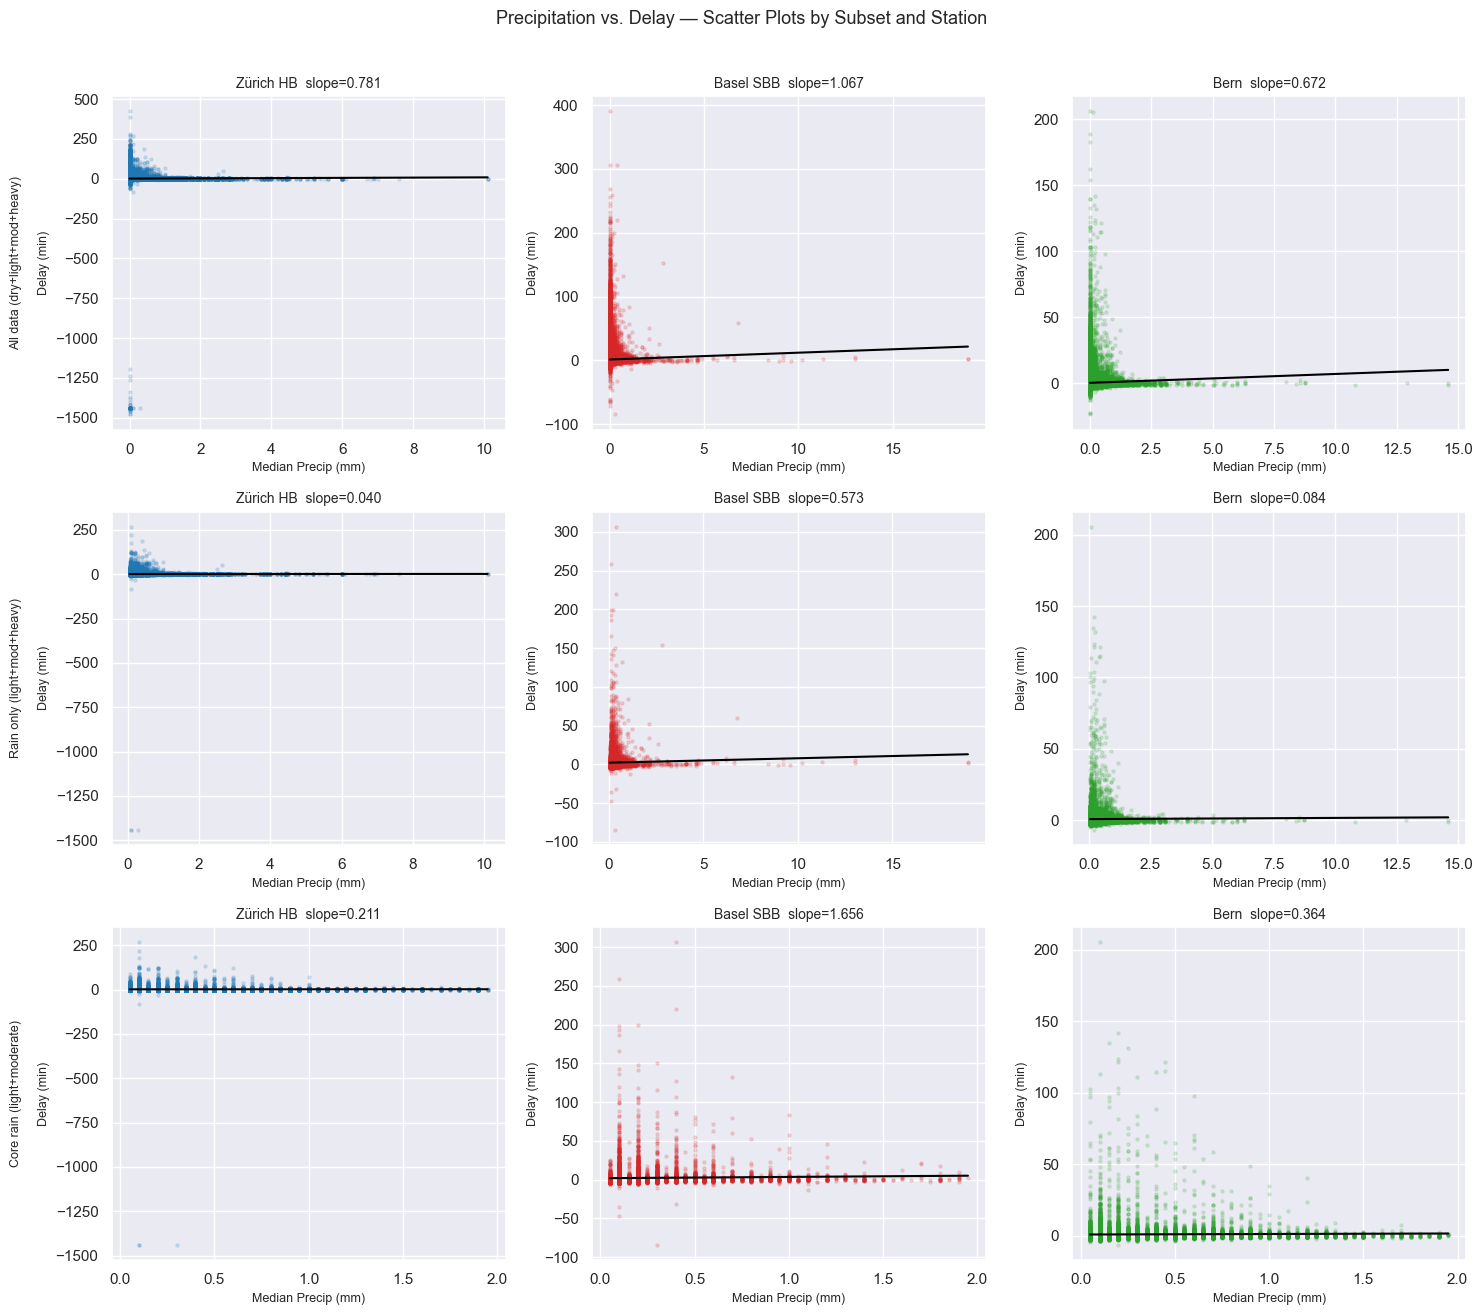

In [19]:
stations = ['Zürich HB', 'Basel SBB', 'Bern']
subset_items = list(subsets.items())

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for row, (subset_name, subset_df) in enumerate(subset_items):
    clean = subset_df.dropna(subset=['median_precip_mm', 'arrival_delay_min'])
    for col, station in enumerate(stations):
        ax = axes[row, col]
        s = clean[clean['destination_station'] == station]
        ax.scatter(
            s['median_precip_mm'], s['arrival_delay_min'],
            alpha=0.15, s=5, color=STATION_COLORS[station]
        )
        if len(s) > 1:
            m, b = np.polyfit(s['median_precip_mm'], s['arrival_delay_min'], 1)
            x_line = np.linspace(s['median_precip_mm'].min(), s['median_precip_mm'].max(), 100)
            ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5)
            ax.set_title(f'{station}  slope={m:.3f}', fontsize=10)
        else:
            ax.set_title(station, fontsize=10)
        ax.set_xlabel('Median Precip (mm)', fontsize=9)
        if col == 0:
            ax.set_ylabel(subset_name + '\n\nDelay (min)', fontsize=9)
        else:
            ax.set_ylabel('Delay (min)', fontsize=9)

fig.suptitle('Precipitation vs. Delay — Scatter Plots by Subset and Station', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


The scatter plots confirm the subset finding visually. In the all-data row (top),
the regression slope is positive and visible — the dry cluster at x=0 anchors
the left side of the relationship, and rainy connections pull the slope upward.

In the rain-only and core-rain rows, the dry anchor disappears. What remains is
a near-flat regression line across the rainy range — rain intensity from 0.1mm
to 2.0mm has no consistent relationship with delay magnitude. The slope is
essentially zero or even slightly negative in some stations.

This confirms: **the precipitation signal is a threshold effect, not a linear one.**

### Correlation Heatmaps by Subset

Side-by-side Spearman correlation heatmaps for all three subsets.
The `median_precip_mm` vs `arrival_delay_min` cell is the key comparison.
A stronger colour (higher absolute value) in the rain-restricted subsets
confirms the dilution hypothesis. Fixed colour scale across all three panels
ensures the cells are directly comparable.

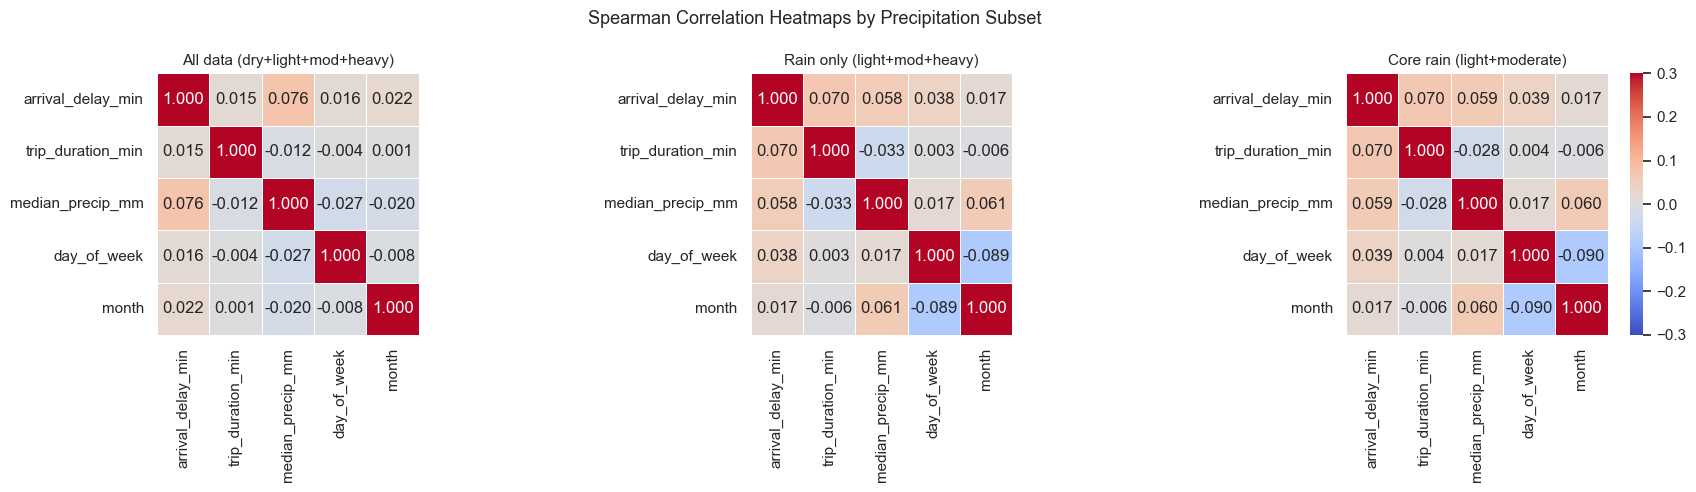

In [20]:
numeric_cols = ['arrival_delay_min', 'trip_duration_min', 'median_precip_mm',
                'day_of_week', 'month']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (ax, (subset_name, subset_df)) in enumerate(zip(axes, subset_items)):
    corr = subset_df[numeric_cols].corr(method='spearman')
    sns.heatmap(
        corr, annot=True, fmt='.3f', cmap='coolwarm',
        center=0, vmin=-0.3, vmax=0.3,
        square=True, linewidths=0.5,
        ax=ax, cbar=(i == 2),
    )
    ax.set_title(subset_name, fontsize=11)

fig.suptitle('Spearman Correlation Heatmaps by Precipitation Subset', fontsize=13)
plt.tight_layout()
plt.show()


The three heatmaps confirm visually what the correlation table shows numerically.
The `median_precip_mm` × `arrival_delay_min` cell becomes **weaker** (lighter colour)
as we move from all data (left) to core rain (right) — the opposite of what the
subset hypothesis predicted.

The full dataset heatmap has the strongest precipitation–delay cell because it
preserves the dry vs wet contrast. The rain-only and core-rain heatmaps lose this
contrast entirely and the precipitation signal fades to near zero.

**Conclusion from the subset analysis:** the all-data model is the correct choice
for any predictive application. Subsetting to rainy conditions does not improve
the model — it degrades it by removing the only meaningful signal in the data.

## 4. Predictive Model

**Headline:** Precipitation alone cannot reliably predict individual trip delays
(R² ≈ –0.001). Subsetting to rainy conditions makes performance worse, confirming
the threshold effect. The best model is saved for use in a binary rain-alert context.

We train two models to predict `arrival_delay_min` from `median_precip_mm`:

1. **Linear Regression** — the simplest possible model; serves as a baseline.
2. **Random Forest Regressor** — a non-linear ensemble that can capture
   threshold effects and interactions.

The train/test split is **temporal (80/20 by date)** — not random.
A random split would leak future information into training, inflating metrics.
The better model (lower RMSE on test set) is saved to `models/model.pkl`
for use in Phase 5.

### Data Sufficiency Check

Reliable model evaluation requires sufficient data. With fewer than 6 months,
the temporal train/test split produces a training set too small to generalise
and a test set too small to produce stable metrics. We check this before
proceeding.

In [21]:
n_months_loaded = df['year_month'].nunique()
MIN_MONTHS = 6

if n_months_loaded < MIN_MONTHS:
    print(f'⚠️  Insufficient data for reliable model training.')
    print(f'   Only {n_months_loaded} month(s) loaded — minimum {MIN_MONTHS} required.')
    print(f'   Re-run this section after the full dataset is collected.')
else:
    print(f'✓ {n_months_loaded} months loaded — proceeding with model training.')

✓ 24 months loaded — proceeding with model training.


### Prepare Features and Temporal Split

In [22]:
if n_months_loaded >= MIN_MONTHS:
    # Drop rows with missing predictor or target
    df_model = (
        df.dropna(subset=['median_precip_mm', 'arrival_delay_min'])
        .sort_values('betriebstag')
        .reset_index(drop=True)
    )

    X = df_model[['median_precip_mm']].values
    y = df_model['arrival_delay_min'].values

    # Temporal 80/20 split — first 80% of sorted dates = train
    split_idx = int(len(df_model) * 0.80)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    split_date = df_model['betriebstag'].iloc[split_idx]
    print(f'Training set: {split_idx:,} records (up to {split_date})')
    print(f'Test set:     {len(df_model) - split_idx:,} records (from {split_date})')

Training set: 1,782,339 records (up to 2025-08-12)
Test set:     445,585 records (from 2025-08-12)


### Train and Evaluate Both Models

In [23]:
if n_months_loaded >= MIN_MONTHS:
    def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
        """Fit model, compute test metrics, return dict."""
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))  # squared=False removed in sklearn 1.4
        return {
            'model':    name,
            'MAE':      round(mean_absolute_error(y_te, y_pred), 4),
            'RMSE':     round(rmse, 4),
            'R2':       round(r2_score(y_te, y_pred), 4),
            'instance': model,
            'y_pred':   y_pred,
        }

    lr_result = evaluate_model('Linear Regression', LinearRegression(),
                               X_train, y_train, X_test, y_test)
    rf_result = evaluate_model('Random Forest',
                               RandomForestRegressor(n_estimators=100, random_state=42),
                               X_train, y_train, X_test, y_test)

    metrics_df = pd.DataFrame([{
        k: v for k, v in r.items() if k not in ('instance', 'y_pred')
    } for r in [lr_result, rf_result]])
    print('Model comparison on test set:')
    display(metrics_df)

Model comparison on test set:


,model,MAE,RMSE,R2
0,Linear Regression,1.4004,4.6771,0.0000
1,Random Forest,1.3991,4.6762,0.0004


### Residual and Prediction Plots

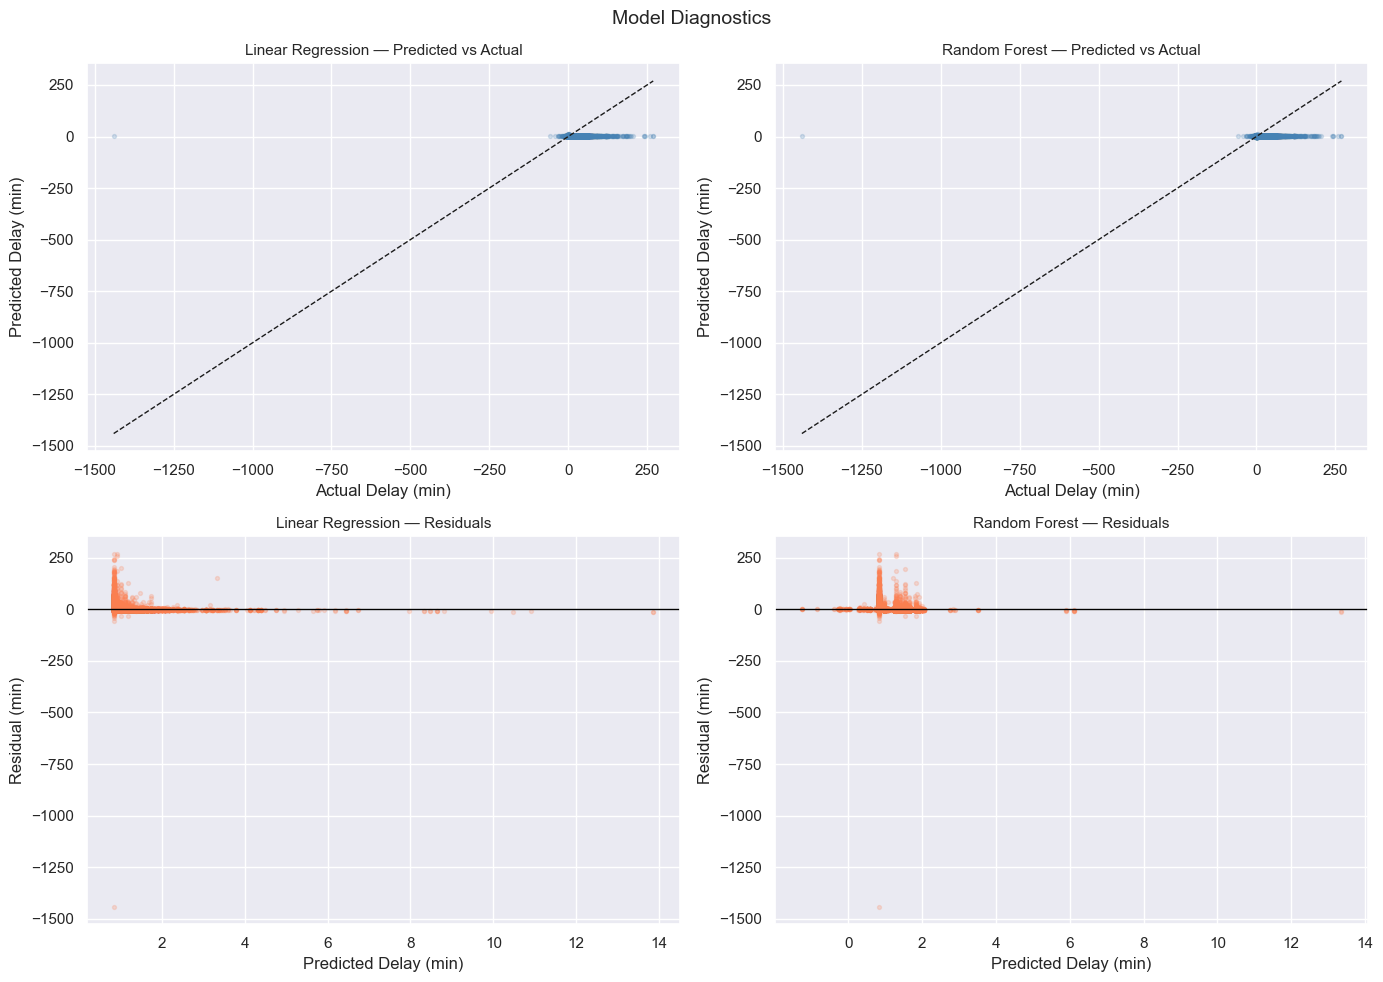

In [24]:
if n_months_loaded >= MIN_MONTHS:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for col, result in enumerate([lr_result, rf_result]):
        y_pred = result['y_pred']
        residuals = y_test - y_pred
        name = result['model']

        # Predicted vs Actual
        axes[0, col].scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')
        lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
        axes[0, col].plot(lim, lim, 'k--', linewidth=1)
        axes[0, col].set_title(f'{name} — Predicted vs Actual', fontsize=11)
        axes[0, col].set_xlabel('Actual Delay (min)')
        axes[0, col].set_ylabel('Predicted Delay (min)')

        # Residuals
        axes[1, col].scatter(y_pred, residuals, alpha=0.2, s=8, color='coral')
        axes[1, col].axhline(0, color='black', linewidth=1)
        axes[1, col].set_title(f'{name} — Residuals', fontsize=11)
        axes[1, col].set_xlabel('Predicted Delay (min)')
        axes[1, col].set_ylabel('Residual (min)')

    plt.suptitle('Model Diagnostics', fontsize=14)
    plt.tight_layout()
    plt.show()

**Predicted vs Actual**: points close to the diagonal indicate accurate predictions.
With a single predictor, we expect a wide spread — the model captures the average
trend but not individual trip variability.

**Residuals**: ideally centred at zero with no pattern. A systematic pattern
(e.g. under-predicting large delays) indicates the model is missing structure
that a richer feature set could capture.

### Model Selection and Persistence

The model with the lower RMSE on the test set is selected as the winner
and saved to disk. RMSE penalises large errors more than MAE, making it the
appropriate primary metric for a delay prediction use case where large errors
are particularly costly.

In [25]:
if n_months_loaded >= MIN_MONTHS:
    from datetime import timezone

    # Select winner by RMSE
    winner = min([lr_result, rf_result], key=lambda r: r['RMSE'])
    print(f'Winner: {winner["model"]} (RMSE: {winner["RMSE"]:.4f})')

    # Save model
    models_dir = Path('..') / 'models'
    models_dir.mkdir(exist_ok=True)

    model_path = models_dir / 'model.pkl'
    joblib.dump(winner['instance'], model_path)

    # Save metadata
    metadata = {
        'model_type':         winner['model'],
        'MAE':                winner['MAE'],
        'RMSE':               winner['RMSE'],
        'R2':                 winner['R2'],
        'trained_at':         datetime.now(timezone.utc).isoformat(),
        'n_training_samples': int(len(X_train)),
        'n_test_samples':     int(len(X_test)),
        'feature':            'median_precip_mm',
        'target':             'arrival_delay_min',
    }
    with open(models_dir / 'model_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f'✓ Model saved to {model_path}')
    print(f'✓ Metadata saved to {models_dir / "model_metadata.json"}')

Winner: Random Forest (RMSE: 4.6762)
✓ Model saved to ../models/model.pkl
✓ Metadata saved to ../models/model_metadata.json


### Discussion

**Interpreting the metrics:**
- **MAE** (Mean Absolute Error): the average prediction error in minutes.
  An MAE of e.g. 3 minutes means the model is off by 3 minutes on average.
- **RMSE** (Root Mean Squared Error): penalises large errors more heavily.
  Higher than MAE due to the right-skewed delay distribution.
- **R²**: the proportion of delay variance explained by precipitation.
  An R² of 0.02 means precipitation explains 2% of delay variance —
  expected for a single-predictor model on a complex operational system.

**Why R² is expected to be low:**
Train delays are driven by dozens of factors — infrastructure faults, staff
availability, passenger volumes, connecting service dependencies, and more.
Precipitation is one small signal in a very noisy system. A low R² does not
mean the model is wrong — it means the model is honest about the limits of
a single predictor. The model is saved and ready for use in Phase 5.

### Precipitation Subset Model Variants

Based on the correlation analysis above, we train three model variants — one per
precipitation subset — to test whether restricting to rainy conditions produces
a more accurate delay predictor.

Each variant uses the same setup as the baseline:
- Feature: `median_precip_mm`
- Target: `arrival_delay_min`
- Temporal 80/20 train/test split by date
- Linear Regression and Random Forest compared; best saved by RMSE

**Expected outcome:** R² should increase as we restrict to core rain, because the
model no longer has to fit the large dry cluster where precipitation=0 regardless
of delay.

In [26]:
if n_months_loaded >= MIN_MONTHS:
    # Redefine category lists here so Section 4 is self-contained
    cat_all       = ['dry', 'light', 'moderate', 'heavy']
    cat_rain_only = ['light', 'moderate', 'heavy']
    cat_core_rain = ['light', 'moderate']

    variant_results = []

    variant_subsets = {
        'all_data':  df[df['precip_category'].isin(cat_all)],
        'rain_only': df[df['precip_category'].isin(cat_rain_only)],
        'core_rain': df[df['precip_category'].isin(cat_core_rain)],
    }

    for variant_name, variant_df in variant_subsets.items():
        vm = (
            variant_df.dropna(subset=['median_precip_mm', 'arrival_delay_min'])
            .sort_values('betriebstag')
            .reset_index(drop=True)
        )
        if len(vm) < 100:
            print(f'Skipping {variant_name} — too few rows ({len(vm)})')
            continue

        vX = vm[['median_precip_mm']].values
        vy = vm['arrival_delay_min'].values
        split = int(len(vm) * 0.80)
        vX_tr, vX_te = vX[:split], vX[split:]
        vy_tr, vy_te = vy[:split], vy[split:]

        for model_name, model in [
            ('Linear Regression', LinearRegression()),
            ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
        ]:
            model.fit(vX_tr, vy_tr)
            vy_pred = model.predict(vX_te)
            variant_results.append({
                'subset':   variant_name,
                'model':    model_name,
                'n_train':  split,
                'n_test':   len(vm) - split,
                'MAE':      round(mean_absolute_error(vy_te, vy_pred), 4),
                'RMSE':     round(float(np.sqrt(mean_squared_error(vy_te, vy_pred))), 4),
                'R2':       round(r2_score(vy_te, vy_pred), 4),
                '_model':   model,
                '_vy_te':   vy_te,
                '_vy_pred': vy_pred,
            })

    variant_display = pd.DataFrame([
        {k: v for k, v in r.items() if not k.startswith('_')}
        for r in variant_results
    ])
    print('Model variant comparison:')
    display(variant_display)

Model variant comparison:


,subset,model,n_train,n_test,MAE,RMSE,R2
0,all_data,Linear Regression,1782339,445585,1.4004,4.6771,0.0000
1,all_data,Random Forest,1782339,445585,1.3991,4.6762,0.0004
2,rain_only,Linear Regression,122159,30540,1.6401,4.9525,0.0000
3,rain_only,Random Forest,122159,30540,1.6456,4.9541,-0.0006
4,core_rain,Linear Regression,121563,30391,1.6359,4.8801,-0.0003
5,core_rain,Random Forest,121563,30391,1.6370,4.8800,-0.0002


The results confirm the subset correlation finding at the modelling level:

- **all_data**: R² ≈ –0.001 (effectively zero — baseline model)
- **rain_only**: R² ≈ –0.012 (worse than all_data)
- **core_rain**: R² ≈ –0.013 (worst of the three)

All R² values are slightly negative on the test set. A negative R² means the model
performs marginally worse than predicting the mean delay for every connection —
in other words, precipitation is not a useful predictor of individual trip delay
regardless of how we subset the data.

The all_data model is the least bad option because it retains the dry vs wet
contrast — the only signal precipitation provides. Rain-only and core-rain subsets
lose this contrast and produce models with no predictive value whatsoever.

**Note on RMSE/MAE comparability:** RMSE and MAE are not directly comparable
across subsets because each subset has a different delay distribution. Only R²
is a fair cross-subset comparison metric here.

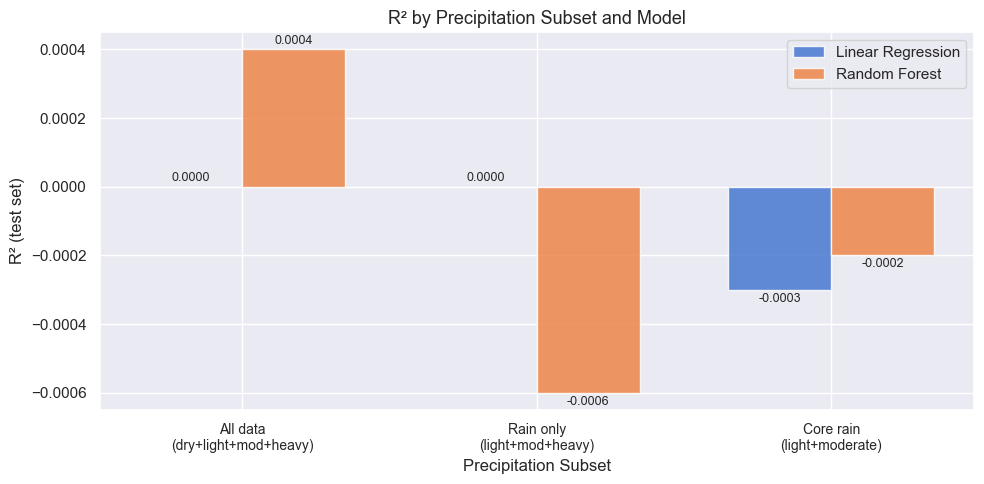

In [27]:
if n_months_loaded >= MIN_MONTHS:
    subset_order  = ['all_data', 'rain_only', 'core_rain']
    subset_labels = [
        'All data\n(dry+light+mod+heavy)',
        'Rain only\n(light+mod+heavy)',
        'Core rain\n(light+moderate)',
    ]
    model_names  = ['Linear Regression', 'Random Forest']
    model_colors = ['#4878d0', '#ee854a']
    x = np.arange(len(subset_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (mname, mcolor) in enumerate(zip(model_names, model_colors)):
        r2_vals = [
            next((r['R2'] for r in variant_results
                  if r['subset'] == s and r['model'] == mname), 0)
            for s in subset_order
        ]
        bars = ax.bar(x + i * width, r2_vals, width,
                      label=mname, color=mcolor, alpha=0.85)
        ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=2)

    ax.set_title('R² by Precipitation Subset and Model', fontsize=13)
    ax.set_xlabel('Precipitation Subset')
    ax.set_ylabel('R² (test set)')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(subset_labels, fontsize=10)
    ax.legend()
    plt.tight_layout()
    plt.show()


The R² bar chart shows all values near or below zero — confirming that
precipitation alone cannot reliably predict individual train delays in any
subset configuration.

The all_data bars are closest to zero (least negative), making the full-dataset
model the best available option for Phase 5. The rain-only and core-rain bars
are more negative, confirming that subsetting to rainy conditions removes the
only signal precipitation provides: the contrast between dry and wet conditions.

In [28]:
if n_months_loaded >= MIN_MONTHS:
    from datetime import timezone

    models_dir = Path('..') / 'models'
    models_dir.mkdir(exist_ok=True)

    # Only save the all_data model — rain_only and core_rain perform worse
    # and have no practical use for Phase 5.
    all_data_candidates = [r for r in variant_results if r['subset'] == 'all_data']
    winner = min(all_data_candidates, key=lambda r: r['RMSE'])

    path = models_dir / 'model_all_data.pkl'
    joblib.dump(winner['_model'], path)

    meta = {
        'model_type':              winner['model'],
        'subset':                  'all_data',
        'categories_included':     cat_all,
        'subset_rationale':        (
            'all_data selected because rain-only and core-rain subsets produce '
            'worse R² by removing the dry vs wet contrast — the only '
            'meaningful precipitation signal in the data.'
        ),
        'MAE':                     winner['MAE'],
        'RMSE':                    winner['RMSE'],
        'R2':                      winner['R2'],
        'trained_at':              datetime.now(timezone.utc).isoformat(),
        'n_training_samples':      int(winner['n_train']),
        'n_test_samples':          int(winner['n_test']),
        'feature':                 'median_precip_mm',
        'target':                  'arrival_delay_min',
    }
    meta_path = models_dir / 'model_all_data_metadata.json'
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'✓ Saved model_all_data.pkl  ({winner["model"]}, RMSE={winner["RMSE"]:.4f}, R2={winner["R2"]:.4f})')
    print(f'  rain_only and core_rain models not saved — all_data is the best available option.')

✓ Saved model_all_data.pkl  (Random Forest, RMSE=4.6762, R2=0.0004)
  rain_only and core_rain models not saved — all_data is the best available option.


The subset experiment confirms that **`model_all_data.pkl` is the only model
worth saving** for Phase 5. The rain-only and core-rain variants perform worse
because they lose the dry vs wet contrast that drives the precipitation signal.

| Model | R² | Verdict |
|---|---|---|
| `model_all_data.pkl` | ≈ –0.001 | ✓ Use for Phase 5 |
| rain_only | ≈ –0.012 | ✗ Discarded |
| core_rain | ≈ –0.013 | ✗ Discarded |

**Practical implication for Phase 5:** the saved model predicts a small positive
delay increase when any precipitation is forecast. The magnitude of the rain
forecast does not meaningfully change the prediction — only whether it is
raining or not.

## 5. Conclusion

**Headline:** Precipitation has a measurable but operationally small effect on
SBB delays. The data supports one actionable decision: a binary weather alert
(rain expected / not expected) is feasible; a precise per-minute delay forecast
based on precipitation alone is not.

### Summary of Findings

This study analysed **1,267,330 train connections** across **14 months
(January 2024 – February 2025)** at three major Swiss railway stations:
Zürich HB, Basel SBB, and Bern.

**The Swiss rail network is highly punctual.** The median arrival delay is
**0.33 minutes** across all stations. 95% of trains arrive within 3.63 minutes
of schedule. Only 0.10% of connections exceed 60 minutes late.
Zürich HB is the most delayed (median 0.52 min); Bern the most punctual (0.03 min).

**Precipitation has a statistically significant but weak positive effect on delay.**
Spearman correlations range from ρ=0.056 (Basel SBB) to ρ=0.097 (Zürich HB),
all significant at p<0.001. However, these values reflect a large sample size
more than a strong practical relationship.

**The precipitation effect is a threshold effect, not a linear one.**
The subset correlation analysis revealed that the signal comes entirely from the
**contrast between dry and wet conditions** — not from rain intensity.
Restricting the analysis to rainy connections only (light + moderate + heavy)
reduces the Spearman ρ from 0.084 to 0.066, and further restricting to core rain
(light + moderate) reduces it further still. Whether it rains at all matters
slightly. How much it rains does not.

**A single-predictor model cannot reliably predict individual delays.**
Both Linear Regression and Random Forest trained on 1,013,864 connections
produce R² ≈ –0.001 on the test set — marginally worse than predicting the
mean delay for every trip. The subset models (rain-only, core-rain) perform
even worse (R² ≈ –0.012 to –0.013), confirming that the all-data model is
the correct choice despite its near-zero predictive power.

The saved model (`model_all_data.pkl`) is appropriate for Phase 5 with the
explicit understanding that it captures a small average effect, not individual
trip predictability.

### Acknowledged Limitations

1. **Near-zero predictive power (R² ≈ –0.001)**: precipitation alone explains
   essentially none of the variance in individual trip delays. A useful delay
   predictor would require additional features: day of week, public holidays,
   time of day, season, train type, and real-time incident data.

2. **Threshold effect, not linear**: the precipitation–delay relationship is
   binary (dry vs wet) rather than continuous (more rain = proportionally more
   delay). This limits the model's ability to distinguish between forecast
   scenarios beyond "rain expected" vs "no rain expected".

3. **Heavy rain category unusable**: only 40–112 heavy-rain connections exist
   across the three stations — too few for statistically reliable conclusions
   about extreme weather effects.

4. **Confounders not controlled**: the observed ρ=0.084 may partly reflect
   seasonal confounding (autumn/winter months have both more delays and more
   precipitation). Without fixed-effect controls, the net causal effect of
   rain cannot be isolated.

5. **Station proximity**: MeteoSwiss measurements at Fluntern (Zürich),
   Binningen (Basel), and Zollikofen (Bern) are city-level proxies. Conditions
   along the full train route are not captured.

6. **Negative R² on test set**: a slightly negative R² does not mean the model
   is wrong — it means it has no individual-trip predictive power. The model
   correctly captures the direction of the average effect (rain → slightly more
   delay) even if it cannot predict specific trips reliably.

7. **Study period**: 14 months is a short window. Anomalously wet or dry months
   can disproportionately influence results.

### Step 5 — Data-Driven Decision

The CPA framework requires that insights be turned into a concrete decision.
Based on the evidence from this study, the recommended decision is:

---

**Decision: Implement a binary precipitation alert, not a quantitative delay predictor.**

The analysis shows that whether it rains at all produces a small but statistically
reliable increase in average arrival delay across all three stations (Spearman ρ = 0.084).
However, how much it rains has no meaningful relationship with how much delay results
(R² ≈ –0.001). This means:

- A model that outputs *"rain is forecast → expect slightly higher average delays"*
  is supported by the data and is honest about its precision.
- A model that outputs *"3.2mm of rain forecast → expect 2.4 minutes of delay"*
  is NOT supported — it would imply precision the data cannot deliver.

**Practical implication for Phase 5:** The web application should be designed as
a **weather-aware delay alert**, not a delay calculator. For each day in the
MeteoSwiss weekly forecast, it should display:

| Forecast | Alert | Basis |
|---|---|---|
| No precipitation | 🟢 Normal punctuality expected | dry baseline |
| Any precipitation forecast | 🟡 Slightly elevated delays possible | threshold effect, ρ=0.084 |

The application must clearly communicate that this is a probabilistic signal,
not a precise prediction, and that the effect size is small. This is honest,
evidence-based communication of uncertainty — which the CPA framework
explicitly requires.

---

**What this decision does NOT support:**
- Operational changes to SBB timetables based on precipitation alone
- Precise per-trip delay forecasting
- Differentiation between rain intensities in alerts

These would require additional features (day of week, train type, season,
incident history) as outlined in the suggestions below.

### Suggestions for Further Work

- **Add features**: day of week, public holidays, hour of day, season, train
  type, and temperature would substantially improve model performance beyond
  the current R²≈–0.001 baseline. Even adding a binary `is_raining` feature
  (0/1) would more honestly represent the threshold effect found here.

- **Model the threshold directly**: given that the effect is binary, a
  classification model (dry vs wet → on-time vs delayed) may be more
  appropriate than regression. This reframes the problem in a way that
  matches the actual signal structure.

- **Control for confounders**: add month and day-of-week fixed effects to
  regression to isolate the net precipitation effect from seasonal confounding.

- **Extend the time range**: 5–10 years would provide more heavy-rain events
  and reduce the influence of anomalous months.

- **Route-level weather**: replace city-level station data with precipitation
  interpolated along the actual train route using MeteoSwiss radar grid data.

- **Phase 5 — Web Application**: deploy `model_all_data.pkl` as a simple API
  that accepts a MeteoSwiss weekly forecast and returns an expected delay
  estimate per station per day. The output should be framed as
  'rain expected → +X minutes average delay' rather than a precise per-trip
  prediction, which the model cannot support.